# 06 · Influence functions and KL modes of the DM

**Who this is for:** you want commands that produce the right mirror *surface*, not just the right values at the actuator positions. Or you have measured influence functions, or want KL modes built for your actual DM.

## Points versus surfaces

The generators sample each mode at the points you give them. With actuator positions, they return commands directly, as if each actuator moved the mirror at a single point. A real DM surface is the sum of each actuator's **influence function** (IF): its surface shape for a unit command, which spreads to its neighbours. If you sample the IFs at pupil points, the surface for commands `c` is

$$ s = \mathrm{IF}\, c, \qquad \mathrm{IF} \in \mathbb{R}^{n_\text{points} \times n_\text{actuators}} .$$

To make a mode `m` on the mirror, evaluate `m` on the pupil points, then find the commands whose surface fits it best: `min ‖IF c − m‖²`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import aobasis

plt.rcParams["figure.dpi"] = 80
D, N_PIX = 10.0, 48

points = aobasis.make_pupil_points(diameter=D, n_pixels=N_PIX)  # pupil pixel centres
pitch = D / 15
actuators = aobasis.make_circular_actuator_grid(D, pitch=pitch)  # inside the pupil
actuators_ring = aobasis.make_circular_actuator_grid(D + 2 * pitch, pitch=pitch)  # + one ring outside
print(len(points), "pupil points;", len(actuators), "actuators inside,", len(actuators_ring), "with the outer ring")


def to_image(values, n_pixels=N_PIX, diameter=D):
    """Put values on pupil points back onto the square pixel grid (NaN outside)."""
    axis = (np.arange(n_pixels) - 0.5 * (n_pixels - 1)) * diameter / n_pixels
    xx, yy = np.meshgrid(axis, axis)
    inside = np.hypot(xx, yy).ravel() <= diameter / 2
    image = np.full(n_pixels * n_pixels, np.nan)
    image[inside] = values
    return image.reshape(n_pixels, n_pixels)


def show_surfaces(surfaces, titles, cmap="RdBu_r"):
    fig, axes = plt.subplots(1, len(titles), figsize=(2.6 * len(titles), 2.6))
    for ax, s, t in zip(np.atleast_1d(axes), surfaces.T, titles):
        lim = np.nanmax(np.abs(s))
        ax.imshow(to_image(s), origin="lower", cmap=cmap, vmin=-lim, vmax=lim)
        ax.set_title(t, fontsize=9)
        ax.axis("off")
    plt.show()

1804 pupil points; 177 actuators inside, 225 with the outer ring


## Influence functions

If you don't have measured IFs, `gaussian_influence_functions` gives the standard model for a continuous facesheet: `coupling ** ((d / pitch)²)`, which is 1 at the actuator and `coupling` (default 0.15) one pitch away.

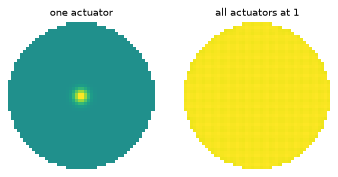

In [2]:
influence = aobasis.gaussian_influence_functions(actuators_ring, points, coupling=0.15, pitch=pitch)
centre = np.argmin(np.hypot(*actuators_ring.T))
show_surfaces(np.column_stack([influence[:, centre], influence.sum(axis=1)]), ["one actuator", "all actuators at 1"], cmap="viridis")

The flat surface (right) shows how well the Gaussians tile the pupil: nearly flat inside, falling off where actuators run out.

## Fitting modes onto the DM

Evaluate the modes on the pupil points, then fit:

(225, 30) commands; relative fitting error of tip, defocus, j=31: [0.011 0.014 0.093]


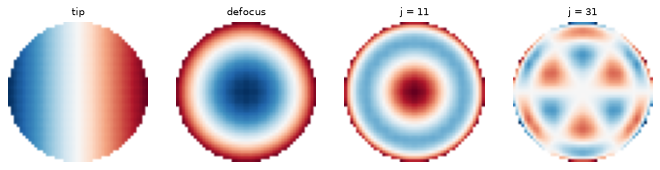

In [3]:
pupil_zernikes = aobasis.ZernikeBasisGenerator(points, pupil_radius=D / 2).generate(30, ignore_piston=True)
commands, residual = aobasis.fit_to_influence_functions(pupil_zernikes, influence, return_residual=True)
print(commands.shape, "commands; relative fitting error of tip, defocus, j=31:", residual[[0, 2, -1]].round(3))
show_surfaces(influence @ commands[:, [0, 2, 9, 29]], ["tip", "defocus", "j = 11", "j = 31"])

Compare with the shortcut, Zernikes sampled at the actuators and used directly as commands. This needs a DM with actuators only inside the pupil:

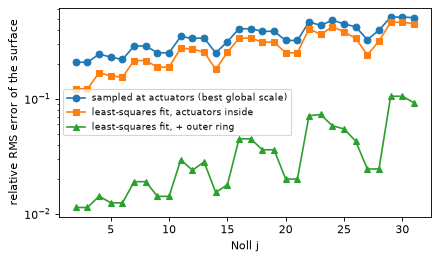

In [4]:
influence_in = aobasis.gaussian_influence_functions(actuators, points, pitch=pitch)
sampled = aobasis.ZernikeBasisGenerator(actuators, pupil_radius=D / 2).generate(30, ignore_piston=True)
_, fit_in = aobasis.fit_to_influence_functions(pupil_zernikes, influence_in, return_residual=True)
scale = np.linalg.lstsq((influence_in @ sampled).ravel()[:, None], pupil_zernikes.ravel(), rcond=None)[0][0]
point_error = np.linalg.norm(scale * influence_in @ sampled - pupil_zernikes, axis=0) / np.linalg.norm(pupil_zernikes, axis=0)

plt.figure(figsize=(6, 3.4))
plt.semilogy(np.arange(2, 32), point_error, "o-", label="sampled at actuators (best global scale)")
plt.semilogy(np.arange(2, 32), fit_in, "s-", label="least-squares fit, actuators inside")
plt.semilogy(np.arange(2, 32), residual, "^-", label="least-squares fit, + outer ring")
plt.xlabel("Noll j")
plt.ylabel("relative RMS error of the surface")
plt.legend(fontsize=8)
plt.show()

Two lessons:

1. **Fitting beats sampling** for every mode, even after giving the sampled commands their best overall gain.
2. **Coverage matters.** With actuators only inside the pupil, the surface droops at the edge. One ring of actuators outside the pupil, as real DMs have, cuts the low-order errors by an order of magnitude.

## Badly seen actuators: `rcond` and `regularization`

Outer-ring actuators that barely touch the pupil are poorly constrained. A pure least-squares fit can give them huge commands that cancel each other. Two controls help:

- `rcond` drops singular directions weaker than `rcond × strongest` (default 1e-6);
- `regularization` adds a Tikhonov penalty on the command norm, in units of the mean diagonal of IFᵀIF.

In [5]:
for reg in (0.0, 1e-3, 1e-2):
    c, res = aobasis.fit_to_influence_functions(pupil_zernikes, influence, regularization=reg, return_residual=True)
    print(f"regularization={reg:<6}: largest |command| {np.abs(c).max():6.2f}, mean fitting error {res.mean():.3f}")

regularization=0.0   : largest |command|  15.65, mean fitting error 0.037
regularization=0.001 : largest |command|  13.05, mean fitting error 0.038
regularization=0.01  : largest |command|   7.17, mean fitting error 0.060


Regularization trades command size for fitting error: 1e-3 trims the largest command by about 15% at no visible cost, while 1e-2 halves it but raises the error by about 60%. Choose it from your DM's stroke budget.

## Orthonormal surfaces

`orthonormalize=True` transforms the commands so that the *surfaces* are orthonormal over the pupil, with unit RMS and mutually orthogonal. Then modal coefficients are RMS wavefront and modes don't cross-talk optically.

In [6]:
ortho = aobasis.fit_to_influence_functions(pupil_zernikes, influence, orthonormalize=True)
s = influence @ ortho
print("largest deviation of SᵀS / n_points from I:", np.abs(s.T @ s / len(points) - np.eye(30)).max().round(12))

largest deviation of SᵀS / n_points from I: 0.0


## KL modes of the DM

`KLBasisGenerator` diagonalizes the turbulence covariance at the actuators. `DMKLBasisGenerator` uses the influence functions instead, through Gendron's double diagonalization:

1. whiten the geometric covariance Δ = IFᵀIF / n, so the candidate surfaces are orthonormal over the pupil;
2. diagonalize the turbulence covariance projected on those surfaces.

The resulting commands produce **orthonormal surfaces with statistically independent coefficients**. They're the best basis for correcting turbulence with *this* DM.

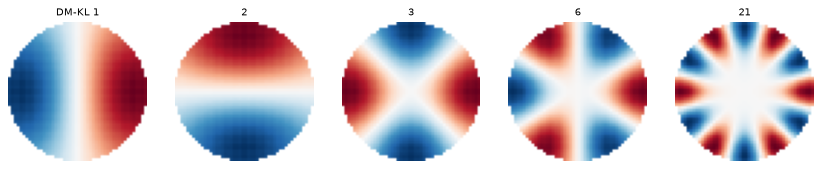

In [7]:
dmkl = aobasis.DMKLBasisGenerator(actuators_ring, points, influence, fried_parameter=0.15, outer_scale=25.0)
m2c = dmkl.generate(60, ignore_piston=True)
show_surfaces(dmkl.surfaces[:, [0, 1, 2, 5, 20]], ["DM-KL 1", "2", "3", "6", "21"])

How much turbulence does each basis let this DM correct? For orthonormal surfaces S, the captured variance is trace(Sᵀ C S) / n²:

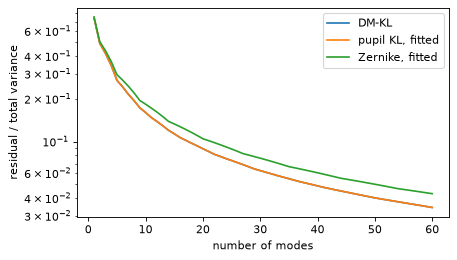

In [8]:
turbulence = aobasis.KLBasisGenerator(points, fried_parameter=0.15, outer_scale=25.0)
cov = turbulence._von_karman_covariance_cpu()
p = np.eye(len(points)) - 1.0 / len(points)
cov = p @ cov @ p
total = np.trace(cov) / len(points)

def captured(commands):
    surfaces = influence @ commands
    return np.cumsum(np.einsum("ik,ij,jk->k", surfaces, cov, surfaces)) / len(points) ** 2

point_kl = aobasis.KLBasisGenerator(points, fried_parameter=0.15, outer_scale=25.0).generate(60, ignore_piston=True)
fitted_kl = aobasis.fit_to_influence_functions(point_kl, influence, orthonormalize=True)
fitted_zern = aobasis.fit_to_influence_functions(
    aobasis.ZernikeBasisGenerator(points, D / 2).generate(60, ignore_piston=True), influence, orthonormalize=True
)

plt.figure(figsize=(6, 3.4))
for name, c in (("DM-KL", m2c), ("pupil KL, fitted", fitted_kl), ("Zernike, fitted", fitted_zern)):
    plt.semilogy(np.arange(1, 61), 1 - captured(c) / total, label=name)
plt.xlabel("number of modes")
plt.ylabel("residual / total variance")
plt.legend()
plt.show()

DM-KL is optimal by construction. Fitted pupil KL modes come so close that the two curves overlap, and fitted Zernikes trail. DM-KL gets there without a separate fitting step, and its modes are exactly orthonormal on the DM.

`DMKLBasisGenerator` accepts the same `ignore_piston`, `remove=` (e.g. `"tiptilt"`) and `normalize=` options as the other generators. Removed modes are kept out of the DM surfaces exactly, even though the DM can't produce them exactly.

## Using measured influence functions

Measured IFs usually come as a cube, `(n_actuators, ny, nx)`, on a pupil image. Flatten them to the pupil pixels and pass the pixel coordinates as `points`:

```python
cube = np.load("measured_ifs.npy")                 # (n_actuators, ny, nx)
pupil = np.load("pupil_mask.npy").astype(bool)     # (ny, nx)
influence = cube[:, pupil].T                       # (n_points, n_actuators)
points = aobasis.positions_from_mask(pupil, pitch=pixel_size_in_metres)
commands = aobasis.fit_to_influence_functions(modes_on(points), influence, regularization=1e-3)
```

`positions_from_mask` walks the pixels in the same row-major order as `cube[:, pupil]`, so points and IF rows line up.